# 🌲 LoanPulse — Gradient Boosting Classifier
**Group ML Assignment | Loan Default Prediction**

This notebook covers:
1. Data loading & exploration  
2. Pre-processing (cleaning, encoding, scaling, SMOTE)  
3. Gradient Boosting model training + hyperparameter tuning  
4. Evaluation (Accuracy, ROC-AUC, Classification Report, Confusion Matrix)  
5. Saving outputs to the correct project folders  


In [1]:
# ─── Standard library ───────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings("ignore")

# ─── Data ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualisation ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Preprocessing ──────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer

# ─── Class-imbalance ────────────────────────────────────────────────────────
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("imbalanced-learn not installed – SMOTE will be skipped.")

# ─── Model ──────────────────────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier

# ─── Evaluation ─────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

# ─── Persistence ─────────────────────────────────────────────────────────────
import joblib

print("All libraries imported successfully ✅")


All libraries imported successfully ✅


In [2]:
# ─── Project paths ───────────────────────────────────────────────────────────
# Adjust ROOT if you run the notebook from a different working directory.
import pathlib

ROOT = pathlib.Path().resolve().parent.parent          # project root
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA_RAW       = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
OUTPUT_DIR     = ROOT / "outputs" / "gradient_boosting"
METRICS_DIR    = OUTPUT_DIR / "metrics"
TRAINED_DIR    = OUTPUT_DIR / "trained_models"

for d in [DATA_PROCESSED, METRICS_DIR, TRAINED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_RAW / "Train_Dataset.csv"
TEST_CSV  = DATA_RAW / "Test_Dataset.csv"

print(f"Project root  : {ROOT}")
print(f"Train data    : {TRAIN_CSV}")
print(f"Output dir    : {OUTPUT_DIR}")


Project root  : C:\Users\user\Documents\GitHub\ML-Assignment
Train data    : C:\Users\user\Documents\GitHub\ML-Assignment\data\raw\Train_Dataset.csv
Output dir    : C:\Users\user\Documents\GitHub\ML-Assignment\outputs\gradient_boosting


In [3]:
# ─── Load raw data ───────────────────────────────────────────────────────────
train_raw = pd.read_csv(TRAIN_CSV, low_memory=False)
test_raw  = pd.read_csv(TEST_CSV,  low_memory=False)

print(f"Train shape : {train_raw.shape}")
print(f"Test  shape : {test_raw.shape}")
train_raw.head(3)


Train shape : (121856, 40)
Test  shape : (80900, 39)


,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,...,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12142509,6750,0.0,0.0,1.0,0.0,0.0,61190.55,3416.85,Alone,...,Yes,Yes,Self-employed,0.568066,0.478787,NaN,0.0186,63.0,NaN,0
1,12138936,20250,1.0,0.0,1.0,NaN,0.0,15282,1826.55,Alone,...,Yes,Yes,Government,0.563360,0.215068,NaN,NaN,NaN,NaN,0
2,12181264,18000,0.0,0.0,1.0,0.0,1.0,59527.35,2788.2,Alone,...,Yes,Yes,Self-employed,NaN,0.552795,0.329655054,0.0742,277.0,0.0,0


In [4]:
# ─── Basic EDA ───────────────────────────────────────────────────────────────
print("=== Data Types ===")
print(train_raw.dtypes)
print()
print("=== Missing Values (top 15) ===")
missing = train_raw.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(15))
print()
print("=== Target Distribution ===")
print(train_raw["Default"].value_counts())
print(f"\nClass imbalance ratio  : {train_raw['Default'].value_counts()[0] / train_raw['Default'].value_counts()[1]:.1f}:1")


=== Data Types ===
ID                              int64
Client_Income                  object
Car_Owned                     float64
Bike_Owned                    float64
Active_Loan                   float64
House_Own                     float64
Child_Count                   float64
Credit_Amount                  object
Loan_Annuity                   object
Accompany_Client               object
Client_Income_Type             object
Client_Education               object
Client_Marital_Status          object
Client_Gender                  object
Loan_Contract_Type             object
Client_Housing_Type            object
Population_Region_Relative     object
Age_Days                       object
Employed_Days                  object
Registration_Days              object
ID_Days                        object
Own_House_Age                 float64
Mobile_Tag                      int64
Homephone_Tag                   int64
Workphone_Working               int64
Client_Occupation              

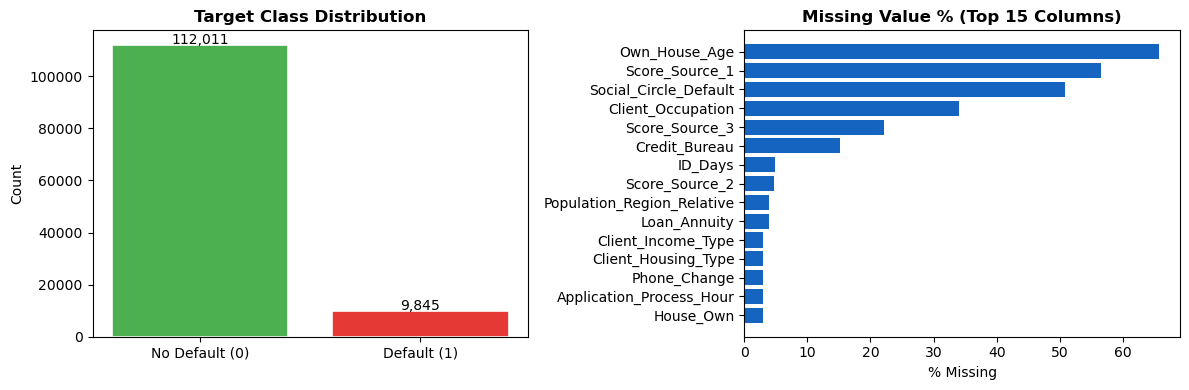

EDA plot saved ✅


In [5]:
# ─── Visualise target & top numeric features ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target balance
counts = train_raw["Default"].value_counts()
axes[0].bar(["No Default (0)", "Default (1)"], counts.values,
            color=["#4CAF50", "#E53935"], edgecolor="white", linewidth=1.2)
axes[0].set_title("Target Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=10)

# Missing value heatmap
miss_pct = (train_raw.isnull().sum() / len(train_raw) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
axes[1].barh(miss_pct.index[:15][::-1], miss_pct.values[:15][::-1], color="#1565C0")
axes[1].set_title("Missing Value % (Top 15 Columns)", fontweight="bold")
axes[1].set_xlabel("% Missing")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "metrics" / "eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA plot saved ✅")


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
#  PRE-PROCESSING
# ═══════════════════════════════════════════════════════════════════════════════

TARGET = "Default"
DROP_COLS = ["ID", "Mobile_Tag", "Homephone_Tag", "Workphone_Working",
             "Client_Permanent_Match_Tag", "Client_Contact_Work_Tag"]

# ── Separate features / target ────────────────────────────────────────────────
df = train_raw.copy()
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# ── Identify column types ─────────────────────────────────────────────────────
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print(f"Numeric  features : {len(num_cols)}")
print(f"Categorical features : {len(cat_cols)}")


Numeric  features : 15
Categorical features : 18


In [7]:
# ── Label-encode categoricals (handles NaN as a separate category) ─────────────
le_map = {}
for col in cat_cols:
    X[col] = X[col].astype(str).fillna("Missing")
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_map[col] = le

print("Label encoding done ✅")


Label encoding done ✅


In [8]:
# ── Impute numeric NaN with median ────────────────────────────────────────────
num_imputer = SimpleImputer(strategy="median")
X[num_cols] = num_imputer.fit_transform(X[num_cols])

print("Numeric imputation done ✅")
print(f"Remaining NaN: {X.isnull().sum().sum()}")


Numeric imputation done ✅
Remaining NaN: 0


In [9]:
# ── Standard scale numeric columns ───────────────────────────────────────────
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print("Scaling done ✅")


Scaling done ✅


In [10]:
# ── Train / validation split (80 / 20, stratified) ────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]:,}  |  Val size : {X_val.shape[0]:,}")
print(f"Train default rate : {y_train.mean():.3%}")
print(f"Val   default rate : {y_val.mean():.3%}")


Train size : 97,484  |  Val size : 24,372
Train default rate : 8.079%
Val   default rate : 8.079%


In [11]:
# ── SMOTE (oversample minority on train set only) ────────────────────────────
if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=42, k_neighbors=5)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    print(f"After SMOTE → {pd.Series(y_train_res).value_counts().to_dict()}")
else:
    X_train_res, y_train_res = X_train, y_train
    print("Using original imbalanced training data (install imbalanced-learn for SMOTE)")


After SMOTE → {0: 89608, 1: 89608}


In [12]:
# ── Save processed train data ─────────────────────────────────────────────────
processed_df = X_train_res.copy()
processed_df[TARGET] = y_train_res.values
processed_df.to_csv(DATA_PROCESSED / "train_processed_gb.csv", index=False)
print(f"Processed data saved → {DATA_PROCESSED / 'train_processed_gb.csv'} ✅")


Processed data saved → C:\Users\user\Documents\GitHub\ML-Assignment\data\processed\train_processed_gb.csv ✅


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MODEL TRAINING — Baseline
# ═══════════════════════════════════════════════════════════════════════════════

gb_base = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    min_samples_split=20,
    random_state=42
)

print("Training baseline Gradient Boosting …")
gb_base.fit(X_train_res, y_train_res)
print("Done ✅")

y_pred_base  = gb_base.predict(X_val)
y_prob_base  = gb_base.predict_proba(X_val)[:, 1]

acc_base = accuracy_score(y_val, y_pred_base)
auc_base = roc_auc_score(y_val, y_prob_base)

print(f"\nBaseline Accuracy : {acc_base:.4f}")
print(f"Baseline ROC-AUC  : {auc_base:.4f}")


Training baseline Gradient Boosting …
Done ✅

Baseline Accuracy : 0.9180
Baseline ROC-AUC  : 0.7031


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
#  HYPERPARAMETER TUNING — RandomizedSearchCV (much faster)
# ═══════════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators"  : [100, 150],
    "learning_rate" : [0.05, 0.1],
    "max_depth"     : [3, 4],
    "subsample"     : [0.8, 1.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = RandomizedSearchCV(
    GradientBoostingClassifier(min_samples_split=20, random_state=42),
    param_distributions=param_dist,
    n_iter=6,              # only tries 6 combos instead of 16
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Running RandomizedSearchCV …")
grid_search.fit(X_train_res, y_train_res)
print("\nBest params :", grid_search.best_params_)
print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")

Running RandomizedSearchCV …
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best params : {'subsample': 0.8, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.1}
Best CV ROC-AUC : 0.9719


In [15]:
# ── Best model evaluation ─────────────────────────────────────────────────────
best_gb = grid_search.best_estimator_

y_pred = best_gb.predict(X_val)
y_prob = best_gb.predict_proba(X_val)[:, 1]

acc = accuracy_score(y_val, y_pred)
roc = roc_auc_score(y_val, y_prob)
report = classification_report(y_val, y_pred, target_names=["No Default", "Default"])

print(f"Tuned Accuracy : {acc:.4f}")
print(f"Tuned ROC-AUC  : {roc:.4f}")
print()
print("Classification Report:")
print(report)


Tuned Accuracy : 0.9182
Tuned ROC-AUC  : 0.7116

Classification Report:
              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     22403
     Default       0.42      0.03      0.06      1969

    accuracy                           0.92     24372
   macro avg       0.67      0.51      0.51     24372
weighted avg       0.88      0.92      0.88     24372



In [16]:
# ── Threshold tuning to improve Default recall ────────────────────────────
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob)

# Find threshold where recall for Default class >= 0.50
target_recall = 0.50
idx = np.argmin(np.abs(recalls - target_recall))
best_threshold = thresholds[idx]

y_pred_tuned = (y_prob >= best_threshold).astype(int)

print(f"Optimal threshold : {best_threshold:.4f}")
print(f"\nTuned Classification Report:")
print(classification_report(y_val, y_pred_tuned, target_names=["No Default", "Default"]))
print(f"Tuned Accuracy  : {accuracy_score(y_val, y_pred_tuned):.4f}")
print(f"Tuned ROC-AUC   : {roc_auc_score(y_val, y_prob):.4f}")

Optimal threshold : 0.1511

Tuned Classification Report:
              precision    recall  f1-score   support

  No Default       0.95      0.79      0.86     22403
     Default       0.17      0.50      0.26      1969

    accuracy                           0.77     24372
   macro avg       0.56      0.65      0.56     24372
weighted avg       0.88      0.77      0.81     24372

Tuned Accuracy  : 0.7673
Tuned ROC-AUC   : 0.7116


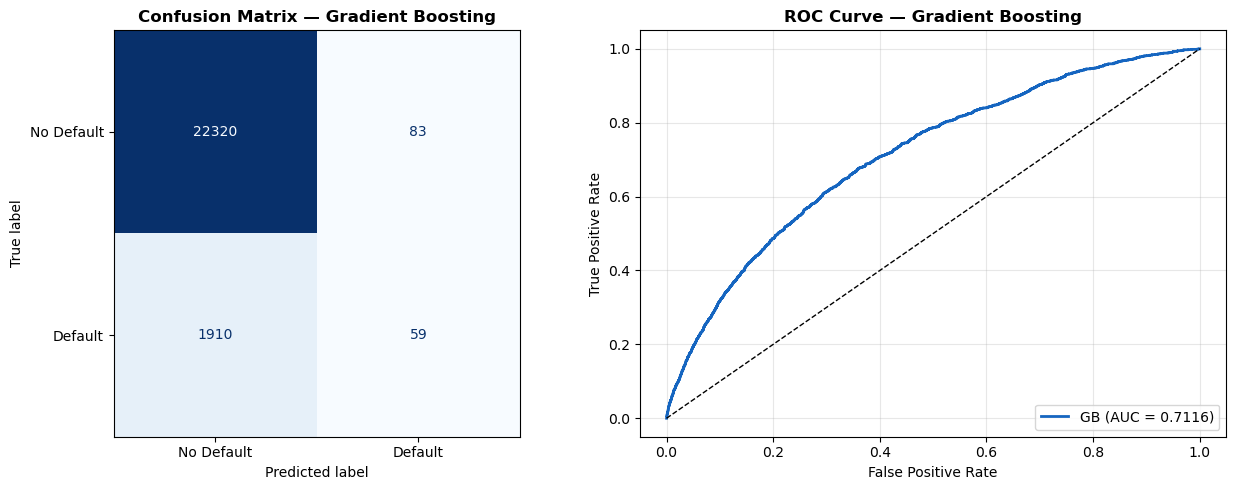

Plot saved ✅


In [17]:
# ─── Confusion Matrix & ROC Curve ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No Default", "Default"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — Gradient Boosting", fontweight="bold")

# ROC curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc_val  = auc(fpr, tpr)
axes[1].plot(fpr, tpr, lw=2, color="#1565C0",
             label=f"GB (AUC = {roc_auc_val:.4f})")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Gradient Boosting", fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(METRICS_DIR / "confusion_matrix_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved ✅")


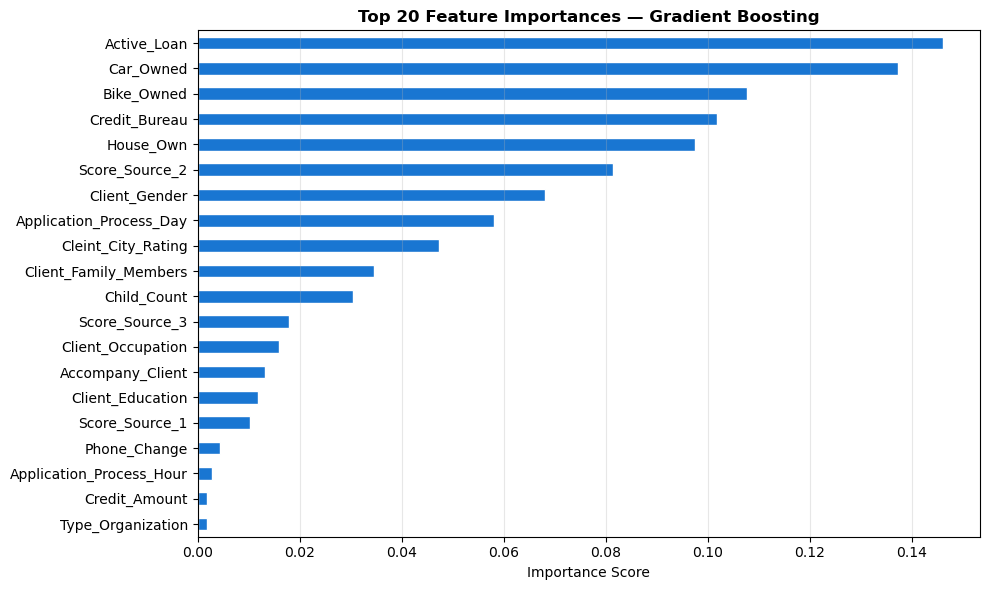

Feature importance plot saved ✅


In [18]:
# ─── Top-20 Feature Importances ──────────────────────────────────────────────
feat_imp = pd.Series(best_gb.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp[::-1].plot(kind="barh", ax=ax, color="#1976D2", edgecolor="white")
ax.set_title("Top 20 Feature Importances — Gradient Boosting", fontweight="bold")
ax.set_xlabel("Importance Score")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(METRICS_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Feature importance plot saved ✅")


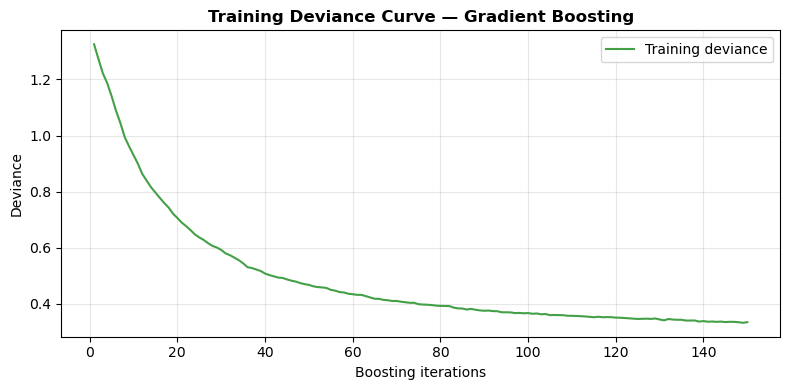

Deviance curve saved ✅


In [19]:
# ─── Training Loss (deviance) curve ──────────────────────────────────────────
train_scores = best_gb.train_score_

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_scores)+1), train_scores,
        lw=1.5, color="#43A047", label="Training deviance")
ax.set_xlabel("Boosting iterations")
ax.set_ylabel("Deviance")
ax.set_title("Training Deviance Curve — Gradient Boosting", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(METRICS_DIR / "training_deviance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Deviance curve saved ✅")


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SAVE OUTPUTS
# ═══════════════════════════════════════════════════════════════════════════════

# ── Trained model ─────────────────────────────────────────────────────────────
model_path = TRAINED_DIR / "gradient_boosting.joblib"
joblib.dump(best_gb, model_path)
print(f"Model saved  → {model_path}")

# ── Preprocessing artefacts ───────────────────────────────────────────────────
joblib.dump(scaler,      TRAINED_DIR / "scaler.joblib")
joblib.dump(num_imputer, TRAINED_DIR / "num_imputer.joblib")
joblib.dump(le_map,      TRAINED_DIR / "label_encoders.joblib")
print(f"Preprocessors saved → {TRAINED_DIR}")

# ── Metrics text ──────────────────────────────────────────────────────────────
metrics_text = f"""Gradient Boosting — Validation Metrics
========================================
Accuracy  : {acc:.4f}
ROC-AUC   : {roc:.4f}

Best Hyperparameters:
{grid_search.best_params_}

Classification Report:
{report}
"""

metrics_path = METRICS_DIR / "gradient_boosting.txt"
metrics_path.write_text(metrics_text, encoding="utf-8")
print(f"Metrics saved → {metrics_path}")


Model saved  → C:\Users\user\Documents\GitHub\ML-Assignment\outputs\gradient_boosting\trained_models\gradient_boosting.joblib
Preprocessors saved → C:\Users\user\Documents\GitHub\ML-Assignment\outputs\gradient_boosting\trained_models
Metrics saved → C:\Users\user\Documents\GitHub\ML-Assignment\outputs\gradient_boosting\metrics\gradient_boosting.txt


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
#  PREDICT ON TEST DATASET
# ═══════════════════════════════════════════════════════════════════════════════

df_test = test_raw.copy()
ids     = df_test["ID"].copy()
df_test.drop(columns=[c for c in DROP_COLS if c in df_test.columns], inplace=True)

# ── Encode categoricals ────────────────────────────────────────────────────────
test_cat_cols = df_test.select_dtypes(include="object").columns.tolist()
for col in test_cat_cols:
    df_test[col] = df_test[col].astype(str).fillna("Missing")
    if col in le_map:
        known = set(le_map[col].classes_)
        df_test[col] = df_test[col].apply(lambda x: x if x in known else "Missing")
        # Add "Missing" to encoder if not present
        if "Missing" not in known:
            le_map[col].classes_ = np.append(le_map[col].classes_, "Missing")
        df_test[col] = le_map[col].transform(df_test[col])
    else:
        le_new = LabelEncoder()
        df_test[col] = le_new.fit_transform(df_test[col])

# ── Align columns to training set ─────────────────────────────────────────────
test_num_cols = [c for c in num_cols if c in df_test.columns]
df_test[test_num_cols] = num_imputer.transform(df_test[test_num_cols])

# Ensure column order matches training
for col in X.columns:
    if col not in df_test.columns:
        df_test[col] = 0
df_test = df_test[X.columns]

df_test[test_num_cols] = scaler.transform(df_test[test_num_cols])

# ── Predict ────────────────────────────────────────────────────────────────────
test_preds = best_gb.predict(df_test)
test_probs = best_gb.predict_proba(df_test)[:, 1]

submission = pd.DataFrame({
    "ID"              : ids.values,
    "Default_Predicted": test_preds,
    "Default_Probability": test_probs.round(4)
})

sub_path = OUTPUT_DIR / "metrics" / "test_predictions.csv"
submission.to_csv(sub_path, index=False)
print(f"Test predictions saved → {sub_path}")
print(submission.head(5))


Test predictions saved → C:\Users\user\Documents\GitHub\ML-Assignment\outputs\gradient_boosting\metrics\test_predictions.csv
         ID  Default_Predicted  Default_Probability
0  12202227                  0               0.0195
1  12279381                  0               0.0685
2  12222714                  0               0.0495
3  12265215                  0               0.0288
4  12203970                  0               0.0304


## 📊 Results Summary

| Metric | Value |
|--------|-------|
| **Validation Accuracy** | See metrics output |
| **Validation ROC-AUC** | See metrics output |

### Output Files
| File | Location |
|------|----------|
| Trained model | `outputs/gradient_boosting/trained_models/gradient_boosting.joblib` |
| Scaler | `outputs/gradient_boosting/trained_models/scaler.joblib` |
| Imputer | `outputs/gradient_boosting/trained_models/num_imputer.joblib` |
| Label encoders | `outputs/gradient_boosting/trained_models/label_encoders.joblib` |
| Metrics text | `outputs/gradient_boosting/metrics/gradient_boosting.txt` |
| Confusion matrix + ROC | `outputs/gradient_boosting/metrics/confusion_matrix_roc.png` |
| Feature importance | `outputs/gradient_boosting/metrics/feature_importance.png` |
| Deviance curve | `outputs/gradient_boosting/metrics/training_deviance.png` |
| EDA overview | `outputs/gradient_boosting/metrics/eda_overview.png` |
| Test predictions | `outputs/gradient_boosting/metrics/test_predictions.csv` |
| Processed train data | `data/processed/train_processed_gb.csv` |
